In [1]:
# Cell 1: Environment Paths & Directory Setup
import logging
from pathlib import Path

# Setup Google Drive mount if running in Google Colab
try:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
    has_colab = True
except Exception:
    has_colab = False

# Path Resolution
DEFAULT_COLAB_ROOT = Path("/content/drive/MyDrive/MPLADs")
ALT_COLAB_ROOT = Path("/content/drive/MYDrive/MPLADs")

if has_colab and DEFAULT_COLAB_ROOT.exists():
    PROJECT_ROOT = DEFAULT_COLAB_ROOT
elif has_colab and ALT_COLAB_ROOT.exists():
    PROJECT_ROOT = ALT_COLAB_ROOT
elif (Path.cwd() / "shared_preprocessing_artifacts").exists():
    PROJECT_ROOT = Path.cwd()
else:
    PROJECT_ROOT = Path.cwd()

SHARED_ARTIFACT_DIR = PROJECT_ROOT / "shared_preprocessing_artifacts"
FEATURE3_ARTIFACT_DIR = PROJECT_ROOT / "feature3_artifacts"
OUTPUT_DIR = PROJECT_ROOT / "feature1_artifacts"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Configure Logging
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s"
)
logger = logging.getLogger("mplads_feature1")

logger.info("Project Root: %s", PROJECT_ROOT)
logger.info("Shared Artifacts Dir: %s", SHARED_ARTIFACT_DIR)
logger.info("Feature 3 Artifacts Dir: %s", FEATURE3_ARTIFACT_DIR)
logger.info("Feature 1 Output Dir: %s", OUTPUT_DIR)

Mounted at /content/drive


In [2]:
# Cell 2: Data Ingestion & Schema Integrity Validation
import pandas as pd
import numpy as np

def read_artifact(dir_path: Path, name: str) -> pd.DataFrame:
    """Reads parquet artifact if available, falling back to CSV."""
    parquet_path = dir_path / f"{name}.parquet"
    csv_path = dir_path / f"{name}.csv"

    if parquet_path.exists():
        try:
            logger.info("Loading parquet: %s", parquet_path)
            return pd.read_parquet(parquet_path)
        except Exception as e:
            logger.warning("Failed loading parquet %s (%s). Falling back to CSV.", parquet_path, e)

    if csv_path.exists():
        logger.info("Loading CSV: %s", csv_path)
        return pd.read_csv(csv_path, low_memory=False)

    raise FileNotFoundError(f"Could not find {name}.parquet or {name}.csv in {dir_path}")

# Load inputs
try:
    fact_work_enriched = read_artifact(FEATURE3_ARTIFACT_DIR, "feature3_fact_work_enriched")
except Exception:
    logger.info("Enriched table not found in feature3_artifacts, checking shared_preprocessing_artifacts...")
    fact_work_enriched = read_artifact(SHARED_ARTIFACT_DIR, "fact_work")

fact_expenditure_rollup = read_artifact(SHARED_ARTIFACT_DIR, "fact_expenditure_rollup")

logger.info("Loaded fact_work shape: %s", fact_work_enriched.shape)
logger.info("Loaded fact_expenditure_rollup shape: %s", fact_expenditure_rollup.shape)

if "work_key" not in fact_work_enriched.columns:
    raise KeyError("Missing required key column 'work_key' in fact_work.")

fe_cols = [
    "work_key", "total_fund_disbursed", "vendor_tranche_count",
    "n_vendors", "first_expenditure_date", "last_expenditure_date",
    "any_success", "any_in_progress"
]
fe_sub = fact_expenditure_rollup[[c for c in fe_cols if c in fact_expenditure_rollup.columns]].drop_duplicates(subset=["work_key"])

# Merge Work Fact with Expenditure Rollup
work_df = fact_work_enriched.merge(fe_sub, on="work_key", how="left", suffixes=("", "_exp"))
logger.info("Merged dataset shape: %s", work_df.shape)

In [3]:
# Disbursement Shortfall & Coverage Calculation
df = work_df.copy()

df["sanction_amount"] = pd.to_numeric(df["sanction_amount"], errors="coerce")
df["amount_disbursed"] = pd.to_numeric(df["amount_disbursed"], errors="coerce")

if "total_fund_disbursed" in df.columns:
    df["total_fund_disbursed"] = pd.to_numeric(df["total_fund_disbursed"], errors="coerce")
else:
    df["total_fund_disbursed"] = np.nan

has_completion_disbursement = df["amount_disbursed"].notna() & (df["amount_disbursed"] > 0)
has_expenditure_tranches = df["total_fund_disbursed"].notna() & (df["total_fund_disbursed"] > 0)

df["effective_disbursed"] = np.where(
    has_completion_disbursement,
    df["amount_disbursed"],
    np.where(has_expenditure_tranches, df["total_fund_disbursed"], np.nan)
)

df["coverage_flag"] = np.where(
    has_completion_disbursement | has_expenditure_tranches,
    "linked",
    "disbursement_unknown"
)

valid_sanction_mask = df["sanction_amount"].notna() & (df["sanction_amount"] > 0)
has_effective_disbursement_mask = df["effective_disbursed"].notna()

df["shortfall_amount"] = np.where(
    valid_sanction_mask & has_effective_disbursement_mask,
    df["sanction_amount"] - df["effective_disbursed"],
    np.nan
)

df["shortfall_pct"] = np.where(
    valid_sanction_mask & has_effective_disbursement_mask,
    (df["effective_disbursed"] - df["sanction_amount"]) / df["sanction_amount"],
    np.nan
)

df["shortfall_deficit_pct"] = np.where(
    df["shortfall_pct"].notna(),
    np.maximum(0.0, -df["shortfall_pct"] * 100.0),
    np.nan
)

logger.info("Coverage distribution:\n%s", df["coverage_flag"].value_counts())
logger.info("Shortfall calculation completed for %d linked records.", df["shortfall_pct"].notna().sum())

In [4]:
# Peer-Group Robust Statistical Anomaly Scoring (Median & MAD)
df["state_key_clean"] = df["state_key"].fillna("UNKNOWN_STATE")
df["category_nlp_clean"] = df["category_nlp"].fillna("Unclassified")
df["peer_group_key"] = df["state_key_clean"] + " | " + df["category_nlp_clean"]

peer_stats = df[df["shortfall_pct"].notna()].groupby("peer_group_key")["shortfall_pct"].agg(
    peer_count="count",
    peer_median_shortfall="median",
    peer_mad_shortfall=lambda x: np.median(np.abs(x - np.median(x)))
).reset_index()

df = df.merge(peer_stats, on="peer_group_key", how="left")

cat_stats = df[df["shortfall_pct"].notna()].groupby("category_nlp_clean")["shortfall_pct"].agg(
    cat_count="count",
    cat_median_shortfall="median",
    cat_mad_shortfall=lambda x: np.median(np.abs(x - np.median(x)))
).reset_index()

df = df.merge(cat_stats, on="category_nlp_clean", how="left")

is_thin_peer_group = df["peer_count"].fillna(0) < 10

df["effective_peer_median"] = np.where(
    is_thin_peer_group,
    df["cat_median_shortfall"].fillna(0.0),
    df["peer_median_shortfall"].fillna(0.0)
)

df["effective_peer_mad"] = np.where(
    is_thin_peer_group,
    df["cat_mad_shortfall"].fillna(0.01),
    df["peer_mad_shortfall"].fillna(0.01)
)

df["peer_group_level"] = np.where(is_thin_peer_group, "category_national", "state_category")

# Domain MAD floor of 0.02 (2% shortfall variance floor) for clean z-score scaling
mad_denominator = np.maximum(1.4826 * df["effective_peer_mad"], 0.02)

df["peer_shortfall_zscore"] = np.where(
    df["shortfall_pct"].notna(),
    (df["effective_peer_median"] - df["shortfall_pct"]) / mad_denominator,
    0.0
)

df["peer_shortfall_zscore"] = np.maximum(0.0, df["peer_shortfall_zscore"])

logger.info("Robust statistical peer scoring complete. Evaluated %d unique peer groups.", df["peer_group_key"].nunique())

In [5]:
# Multivariate Feature Engineering & Isolation Forest ML Augmentation
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer
import joblib

logger.info("--- Starting Multivariate Isolation Forest Pipeline ---")

# 1. Pipeline Status Ordinal Encoding
def map_status_ordinal(status_str: str) -> int:
    if pd.isna(status_str):
        return 0
    s = str(status_str).lower()
    if "completed" in s and "partially" not in s:
        return 3
    elif "partially" in s:
        return 2
    elif any(k in s for k in ["progress", "inspection", "sanction", "identification"]):
        return 1
    return 0

df["work_status_ordinal"] = df["work_status"].apply(map_status_ordinal)

# 2. Days from Sanction to Completion/Last Tranche Calculation
s_date = pd.to_datetime(df["sanction_date"], errors="coerce", dayfirst=True)
c_date = pd.to_datetime(df.get("completion_date", pd.Series(np.nan, index=df.index)), errors="coerce", dayfirst=True)
l_date = pd.to_datetime(df.get("last_expenditure_date", pd.Series(np.nan, index=df.index)), errors="coerce", dayfirst=True)

end_date = c_date.fillna(l_date)
df["days_sanction_to_last_tranche"] = (end_date - s_date).dt.days
# Clip negative or unrealistically long dates
df["days_sanction_to_last_tranche"] = np.clip(df["days_sanction_to_last_tranche"], 0, 1825)

# 3. Log Sanction Amount
df["log_sanction_amount"] = np.log1p(np.maximum(0.0, df["sanction_amount"].fillna(0.0)))

# 4. Expenditure tranche count
df["tranche_count_clean"] = df.get("vendor_tranche_count", pd.Series(0, index=df.index)).fillna(0).astype(float)

# 5. Assemble Multivariate Feature Matrix
multivariate_feature_cols = [
    "shortfall_deficit_pct",
    "tranche_count_clean",
    "days_sanction_to_last_tranche",
    "work_status_ordinal",
    "log_sanction_amount"
]

logger.info("Multivariate features used for Isolation Forest: %s", multivariate_feature_cols)

# Train Isolation Forest on linked records with non-null sanction amount
linked_mask = (df["coverage_flag"] == "linked") & (df["sanction_amount"] > 0)
X_raw = df.loc[linked_mask, multivariate_feature_cols].copy()

# Impute & Scale Features
imputer = SimpleImputer(strategy="median")
scaler = RobustScaler()

X_imputed = imputer.fit_transform(X_raw)
X_scaled = scaler.fit_transform(X_imputed)

# Fit Isolation Forest Model
iforest = IsolationForest(
    n_estimators=100,
    contamination=0.03,
    random_state=42,
    n_jobs=-1
)
iforest.fit(X_scaled)

# Score samples: IsolationForest outputs lower scores for anomalies.
# Invert score so HIGHER value means MORE ANOMALOUS.
raw_iforest_scores = -iforest.score_samples(X_scaled)

# Scale score to [0.0, 1.0] range
score_min, score_max = raw_iforest_scores.min(), raw_iforest_scores.max()
if score_max > score_min:
    norm_iforest_scores = (raw_iforest_scores - score_min) / (score_max - score_min)
else:
    norm_iforest_scores = np.zeros_like(raw_iforest_scores)

# Assign Isolation Forest anomaly score back to dataframe
df["iforest_anomaly_score"] = np.nan
df.loc[linked_mask, "iforest_anomaly_score"] = norm_iforest_scores

# Save trained Isolation Forest model & pipeline artifacts
iforest_model_path = OUTPUT_DIR / "feature1_isolation_forest.joblib"
joblib.dump({
    "imputer": imputer,
    "scaler": scaler,
    "model": iforest,
    "feature_cols": multivariate_feature_cols,
    "score_min": float(score_min),
    "score_max": float(score_max)
}, iforest_model_path)

logger.info("Isolation Forest model trained on %d linked works and saved to %s", linked_mask.sum(), iforest_model_path)

In [6]:
# Completion Integrity Rules & Unified Blended Risk Score
df["status_str"] = df["work_status"].fillna("").astype(str)
df["is_completed"] = df["status_str"].str.contains("Completed", case=False) & ~df["status_str"].str.contains("partially", case=False)
df["is_partially_completed"] = df["status_str"].str.contains("partially", case=False)
df["is_in_progress"] = df["status_str"].str.contains("Progress|Inspection|Sanction|Identification", case=False)

# Completion Integrity Anomaly Flags
df["is_closed_with_shortfall"] = df["is_completed"] & (df["shortfall_deficit_pct"] > 10.0)
df["severe_completion_shortfall"] = df["is_completed"] & (df["shortfall_deficit_pct"] > 30.0)
df["critical_completion_shortfall"] = df["is_completed"] & (df["shortfall_deficit_pct"] > 50.0)

# Normalized sub-scores
z_norm = np.clip(df["peer_shortfall_zscore"] / 4.0, 0.0, 1.0)
deficit_norm = np.clip(df["shortfall_deficit_pct"].fillna(0.0) / 100.0, 0.0, 1.0)
iforest_norm = df["iforest_anomaly_score"].fillna(0.0)

integrity_boost = np.where(
    df["critical_completion_shortfall"],
    0.35,
    np.where(df["severe_completion_shortfall"], 0.20, np.where(df["is_closed_with_shortfall"], 0.10, 0.0))
)

# Unified Blended Risk Score [0.0 - 1.0]
# Weights: 25% Univariate Z-Score + 35% Shortfall Deficit Magnitude + 20% Isolation Forest Multivariate Score + Integrity Boost
df["disbursement_risk_score"] = np.where(
    df["coverage_flag"] == "linked",
    np.clip(0.25 * z_norm + 0.35 * deficit_norm + 0.20 * iforest_norm + integrity_boost, 0.0, 1.0),
    np.nan
)

# Risk Tier Categorization
def assign_risk_tier(row: pd.Series) -> str:
    if row["coverage_flag"] == "disbursement_unknown":
        return "Unknown / Unlinked"

    score = row["disbursement_risk_score"]
    is_comp = row["is_completed"]
    def_pct = row["shortfall_deficit_pct"]

    if score >= 0.70 or (is_comp and def_pct >= 50.0):
        return "Critical"
    elif score >= 0.50 or (is_comp and def_pct >= 25.0):
        return "High"
    elif score >= 0.30:
        return "Medium"
    else:
        return "Low"

df["disbursement_risk_tier"] = df.apply(assign_risk_tier, axis=1)

print("--- Feature 1 Risk Tier Distribution (with Isolation Forest ML) ---")
print(df["disbursement_risk_tier"].value_counts(dropna=False))

--- Feature 1 Risk Tier Distribution (with Isolation Forest ML) ---
disbursement_risk_tier
Low                   27763
Unknown / Unlinked    14137
High                    581
Medium                  550
Critical                119
Name: count, dtype: int64


In [7]:
# Dashboard Explanation Generator

def generate_dashboard_explanation(row: pd.Series) -> str:
    """Generates clear, natural language explanation strings for dashboard display."""
    if row["coverage_flag"] == "disbursement_unknown":
        return "Disbursement status unknown: No linked payment tranches or completion disbursement amount recorded."

    sanction = row["sanction_amount"]
    disbursed = row["effective_disbursed"]
    deficit_pct = row["shortfall_deficit_pct"]
    zscore = row["peer_shortfall_zscore"]
    if_score = row.get("iforest_anomaly_score", np.nan)
    status = row["work_status"] if pd.notna(row["work_status"]) else "Unknown Status"
    state = row["state"] if pd.notna(row["state"]) else "State"
    cat = row["category_nlp"] if pd.notna(row["category_nlp"]) else "General Work"

    z_str = f">{10.0:.1f}σ" if zscore >= 10.0 else f"{zscore:.1f}σ"

    ml_note = f" (Multivariate Isolation Forest anomaly score: {if_score:.2f})" if pd.notna(if_score) and if_score >= 0.60 else ""

    if row["critical_completion_shortfall"]:
        return (
            f"CRITICAL INTEGRITY ANOMALY: Work marked '{status}' with sanctioned cost ₹{sanction:,.0f}, "
            f"but realized disbursement is only ₹{disbursed:,.0f} ({deficit_pct:.1f}% shortfall). "
            f"Shortfall is {z_str} higher than the {state} ({cat}) peer group median.{ml_note}"
        )
    elif row["severe_completion_shortfall"]:
        return (
            f"HIGH COMPLETION SHORTFALL: Work marked '{status}' with sanctioned cost ₹{sanction:,.0f}, "
            f"realized disbursement of ₹{disbursed:,.0f} ({deficit_pct:.1f}% shortfall). "
            f"Exceeds expected peer median by {z_str}.{ml_note}"
        )
    elif pd.notna(if_score) and if_score >= 0.70 and deficit_pct <= 10.0:
        return (
            f"MULTIVARIATE ANOMALY DETECTED: Project displays unusual combination of cost, status, duration, and tranche patterns "
            f"(Isolation Forest Anomaly Score: {if_score:.2f}) despite low univariate shortfall."
        )
    elif deficit_pct > 15.0:
        return (
            f"MODERATE DISBURSEMENT SHORTFALL: Realized disbursement ₹{disbursed:,.0f} is {deficit_pct:.1f}% "
            f"below sanctioned amount of ₹{sanction:,.0f} under status '{status}'.{ml_note}"
        )
    elif deficit_pct <= 0.01:
        return f"NORMAL DISBURSEMENT: Full funding disbursed (₹{disbursed:,.0f} out of ₹{sanction:,.0f} sanctioned)."
    else:
        return f"MINOR VARIANCE: Realized disbursement ₹{disbursed:,.0f} is {deficit_pct:.1f}% below sanctioned amount ₹{sanction:,.0f}."

df["disbursement_risk_explanation"] = df.apply(generate_dashboard_explanation, axis=1)

print("--- Sample Critical Dashboard Explanations ---")
critical_samples = df[df["disbursement_risk_tier"] == "Critical"]["disbursement_risk_explanation"].head(5)
for i, exp in enumerate(critical_samples, 1):
    print(f"{i}. {exp}\n")

--- Sample Critical Dashboard Explanations ---
1. CRITICAL INTEGRITY ANOMALY: Work marked 'Work Completed' with sanctioned cost ₹100,000, but realized disbursement is only ₹47,627 (52.4% shortfall). Shortfall is >10.0σ higher than the Andhra Pradesh (Road & Pathway Infrastructure) peer group median. (Multivariate Isolation Forest anomaly score: 0.82)

2. MODERATE DISBURSEMENT SHORTFALL: Realized disbursement ₹12,503 is 93.7% below sanctioned amount of ₹200,000 under status 'Physical Inspection'. (Multivariate Isolation Forest anomaly score: 0.89)

3. MODERATE DISBURSEMENT SHORTFALL: Realized disbursement ₹196,013 is 85.6% below sanctioned amount of ₹1,363,000 under status 'Work partially Completed'. (Multivariate Isolation Forest anomaly score: 0.80)

4. MODERATE DISBURSEMENT SHORTFALL: Realized disbursement ₹108,155 is 95.7% below sanctioned amount of ₹2,500,000 under status 'Work partially Completed'. (Multivariate Isolation Forest anomaly score: 0.88)

5. HIGH COMPLETION SHORTFALL: 

In [8]:
# Summary Analysis & Top Anomaly Worklist Display
display_cols = [
    "work_id", "state", "district_name", "category_nlp", "work_status",
    "sanction_amount", "effective_disbursed", "shortfall_deficit_pct",
    "peer_shortfall_zscore", "iforest_anomaly_score", "disbursement_risk_score", "disbursement_risk_tier",
    "disbursement_risk_explanation"
]

critical_worklist = df[df["disbursement_risk_tier"] == "Critical"].sort_values(
    by=["disbursement_risk_score", "shortfall_deficit_pct"],
    ascending=[False, False]
)

print(f"Total Critical Anomalies Identified: {len(critical_worklist)}")
print("\n--- Top 10 Critical Disbursement Shortfall Anomalies ---")
if len(critical_worklist) > 0:
    display_df = critical_worklist[display_cols].head(10)
    try:
        from IPython.display import display
        display(display_df)
    except Exception:
        print(display_df.to_string())

Total Critical Anomalies Identified: 119

--- Top 10 Critical Disbursement Shortfall Anomalies ---


,work_id,state,district_name,category_nlp,work_status,sanction_amount,effective_disbursed,shortfall_deficit_pct,peer_shortfall_zscore,iforest_anomaly_score,disbursement_risk_score,disbursement_risk_tier,disbursement_risk_explanation
6275,WS/MP18157/2024-2025/172488,Punjab,Ludhiana,School & Education Infrastructure,Work Completed,500000.0,141450.0,71.710000,35.855000,0.823916,1.000000,Critical,CRITICAL INTEGRITY ANOMALY: Work marked 'Work ...
30637,WS/MP138/2024-2025/143889,Odisha,Puri,School & Education Infrastructure,Work Completed,800000.0,322015.0,59.748125,29.874062,0.834835,0.976086,Critical,CRITICAL INTEGRITY ANOMALY: Work marked 'Work ...
23708,WS/MP719/2024-2025/154862,Rajasthan,Kekri,Community & Public Buildings,Work Completed,499959.0,192224.0,61.552047,30.776024,0.794221,0.974276,Critical,CRITICAL INTEGRITY ANOMALY: Work marked 'Work ...
9160,WS/MP18219/2025-2026/143336,Uttar Pradesh,Mahoba,Road & Pathway Infrastructure,Work Completed,700000.0,297530.0,57.495714,28.747857,0.821708,0.965577,Critical,CRITICAL INTEGRITY ANOMALY: Work marked 'Work ...
30279,WS/MP113/2025-2026/142031,Maharashtra,Beed,Community & Public Buildings,Work Completed,5000000.0,2385842.0,52.283160,26.141580,0.894292,0.961849,Critical,CRITICAL INTEGRITY ANOMALY: Work marked 'Work ...
34038,WS/MP18296/2025-2026/162108,Karnataka,Kaithal,Road & Pathway Infrastructure,Work Completed,400000.0,178008.0,55.498000,27.749000,0.793350,0.952913,Critical,CRITICAL INTEGRITY ANOMALY: Work marked 'Work ...
338,WS/MP18006/2024-2025/139521,Andhra Pradesh,Chittoor,Road & Pathway Infrastructure,Work Completed,100000.0,47627.0,52.373000,26.186500,0.823701,0.948046,Critical,CRITICAL INTEGRITY ANOMALY: Work marked 'Work ...
12424,WS/MP18253/2025-2026/150568,West Bengal,South 24 Parganas,Road & Pathway Infrastructure,Work Completed,350000.0,163335.0,53.332857,26.666429,0.785639,0.943793,Critical,CRITICAL INTEGRITY ANOMALY: Work marked 'Work ...
6264,WS/MP18157/2024-2025/169462,Punjab,Sri Muktsar Sahib,Road & Pathway Infrastructure,Work Completed,575000.0,285411.0,50.363304,25.181652,0.762100,0.928692,Critical,CRITICAL INTEGRITY ANOMALY: Work marked 'Work ...
34604,WS/MP18304/2024-2025/139898,Himachal Pradesh,Chamba,Road & Pathway Infrastructure,Work Completed,100000.0,50000.0,50.000000,25.000000,0.829695,0.790939,Critical,HIGH COMPLETION SHORTFALL: Work marked 'Work C...


/tmp/ipykernel_5026/1554980659.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


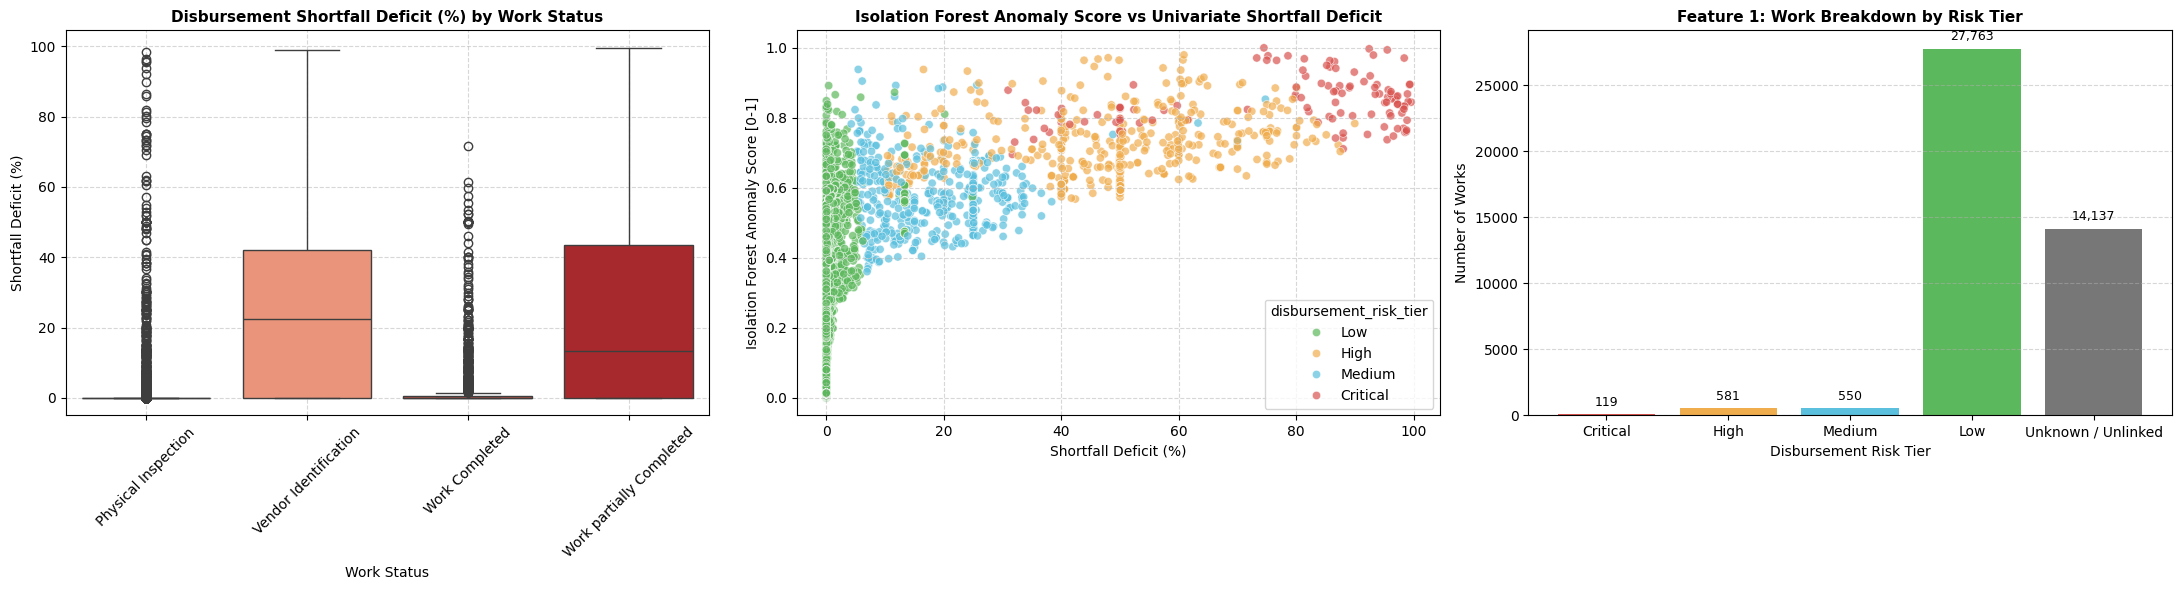

In [9]:
# Visualizations for Dashboard & ML Model Audit
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# Plot 1: Shortfall Deficit % Distribution by Work Status
linked_df = df[df["coverage_flag"] == "linked"].copy()

sns.boxplot(
    data=linked_df,
    x="work_status",
    y="shortfall_deficit_pct",
    ax=axes[0],
    palette="Reds"
)
axes[0].set_title("Disbursement Shortfall Deficit (%) by Work Status", fontsize=11, fontweight="bold")
axes[0].set_xlabel("Work Status", fontsize=10)
axes[0].set_ylabel("Shortfall Deficit (%)", fontsize=10)
axes[0].tick_params(axis="x", rotation=45)
axes[0].grid(True, linestyle="--", alpha=0.5)

# Plot 2: Isolation Forest Anomaly Score vs Shortfall Deficit %
sns.scatterplot(
    data=linked_df,
    x="shortfall_deficit_pct",
    y="iforest_anomaly_score",
    hue="disbursement_risk_tier",
    palette={"Critical": "#d9534f", "High": "#f0ad4e", "Medium": "#5bc0de", "Low": "#5cb85c"},
    ax=axes[1],
    alpha=0.7
)
axes[1].set_title("Isolation Forest Anomaly Score vs Univariate Shortfall Deficit", fontsize=11, fontweight="bold")
axes[1].set_xlabel("Shortfall Deficit (%)", fontsize=10)
axes[1].set_ylabel("Isolation Forest Anomaly Score [0-1]", fontsize=10)
axes[1].grid(True, linestyle="--", alpha=0.5)

# Plot 3: Risk Tier Distribution Count
tier_order = ["Critical", "High", "Medium", "Low", "Unknown / Unlinked"]
tier_counts = df["disbursement_risk_tier"].value_counts().reindex(tier_order).fillna(0)

bars = axes[2].bar(tier_counts.index, tier_counts.values, color=["#d9534f", "#f0ad4e", "#5bc0de", "#5cb85c", "#777777"])
axes[2].set_title("Feature 1: Work Breakdown by Risk Tier", fontsize=11, fontweight="bold")
axes[2].set_xlabel("Disbursement Risk Tier", fontsize=10)
axes[2].set_ylabel("Number of Works", fontsize=10)
axes[2].grid(axis="y", linestyle="--", alpha=0.5)

for bar in bars:
    yval = bar.get_height()
    axes[2].text(bar.get_x() + bar.get_width()/2.0, yval + 400, f"{int(yval):,}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()

# Save plot
plot_path = OUTPUT_DIR / "feature1_shortfall_distribution.png"
plt.savefig(plot_path, dpi=300, bbox_inches="tight")
logger.info("Saved visualization plot to: %s", plot_path)
plt.show()

In [10]:
# Artifact Export & Fact-Table Update
import json
from datetime import datetime, timezone

# 1. Export Feature 1 Enriched Dataset
f1_csv_path = OUTPUT_DIR / "feature1_fact_work_disbursement_risk.csv"
f1_parquet_path = OUTPUT_DIR / "feature1_fact_work_disbursement_risk.parquet"

df.to_csv(f1_csv_path, index=False)
try:
    df.to_parquet(f1_parquet_path, index=False)
except Exception as e:
    logger.warning("Could not export parquet to %s: %s", f1_parquet_path, e)

# 2. Export Critical & High Risk Worklist
worklist_path = OUTPUT_DIR / "feature1_disbursement_risk_worklist.csv"
high_risk_worklist = df[df["disbursement_risk_tier"].isin(["Critical", "High"])].sort_values(
    by=["disbursement_risk_score", "shortfall_deficit_pct"],
    ascending=[False, False]
)
high_risk_worklist.to_csv(worklist_path, index=False)
logger.info("Exported high-risk worklist (%d rows) to: %s", len(high_risk_worklist), worklist_path)

# 3. Export Shared Preprocessing Updated Fact Table for Downstream Features (Features 2, 5, 7)
shared_f1_csv = SHARED_ARTIFACT_DIR / "fact_work_feature1.csv"
shared_f1_parquet = SHARED_ARTIFACT_DIR / "fact_work_feature1.parquet"

df.to_csv(shared_f1_csv, index=False)
try:
    df.to_parquet(shared_f1_parquet, index=False)
    logger.info("Exported canonical updated table to: %s", shared_f1_parquet)
except Exception as e:
    logger.warning("Could not export canonical parquet: %s", e)

# 4. Save Run Metadata JSON
metadata = {
    "feature_name": "Feature 1: Fund Disbursement Shortfall & Completion Integrity Score (with Isolation Forest ML)",
    "created_at_utc": datetime.now(timezone.utc).isoformat(),
    "total_works_processed": int(len(df)),
    "coverage_breakdown": {k: int(v) for k, v in df["coverage_flag"].value_counts().items()},
    "risk_tier_counts": {k: int(v) for k, v in df["disbursement_risk_tier"].value_counts().items()},
    "critical_completion_anomalies_count": int(df["critical_completion_shortfall"].sum()),
    "isolation_forest": {
        "n_estimators": 100,
        "contamination": 0.03,
        "features_used": [
            "shortfall_deficit_pct", "tranche_count_clean", "days_sanction_to_last_tranche",
            "work_status_ordinal", "log_sanction_amount"
        ],
        "model_artifact": str(OUTPUT_DIR / "feature1_isolation_forest.joblib")
    },
    "output_artifacts": {
        "enriched_dataset_csv": str(f1_csv_path),
        "high_risk_worklist_csv": str(worklist_path),
        "canonical_shared_fact_work_csv": str(shared_f1_csv),
        "visualization_png": str(plot_path)
    }
}

metadata_path = OUTPUT_DIR / "feature1_run_metadata.json"
with open(metadata_path, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)

logger.info("Feature 1 execution finished successfully! Metadata saved to: %s", metadata_path)